In [ ]:
import sys
sys.path.append('../../Python_scripts')

## Import packages
from config import *
from support import *
from cosmo_support import *

import sympy as sp

/home/zhuge/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Sigmas=np.load('./interpolation/sigmas.npy')
# Vars_sqrt=np.load('./interpolation/Vars_sqrt.npy')
# C0s=np.load('./interpolation/C0s.npy')
# As=np.load('./interpolation/As.npy')

In [3]:
load_arrays=np.load('./interpolation/068_C0median.npz')
Sigmas=load_arrays['a']
Errors=load_arrays['d']
C0s=load_arrays['c']
As=load_arrays['b']

In [4]:
sigma_error_inter= interpolate.interp1d(Errors, Sigmas, kind=1,bounds_error=False, 
    # fill_value='extrapolate'
    )

In [5]:
C0_sigma_inter = interpolate.interp1d(Sigmas, C0s, kind=1,bounds_error=False, 
    # fill_value='extrapolate'
    )

In [6]:
A_sigma_inter = interpolate.interp1d(Sigmas, As, kind=1,bounds_error=False, 
    # fill_value='extrapolate'
    )

In [ ]:
df=pd.read_excel('../../Data/Zijian_TNG.xlsx')
df=df[df['z'] <= 1.5]
df=df[df['z'] >= 0.1]
# df=df.rename(columns={'sigma':'Var'})
df.head()

,z,A,C0,sigma
0,0.1,0.047210,-13.170,2.5540
1,0.2,0.005693,-1.008,1.1180
2,0.3,0.003584,0.596,0.7043
3,0.4,0.002876,1.010,0.5158
4,0.5,0.002423,1.127,0.4306


In [8]:
# https://arxiv.org/abs/2411.02699
def sigma_z_CoDa2(z):
    a=0.316/(z**0.677)*(z<3.0)
    b=0.310/(z**0.660)*(z>3.0)*(z<7.11)
    c=0.0851*(z>=7.11)
    return a+b+c

# 2010.01560v2.pdf
def sigma_DM_th_z(z):
    return 230*(z**0.5)

In [9]:
z_range=np.linspace(0.2, 10, 100)
sigmas_Macquart=[f_sqrtvar_delta(F_tilde=0.31,z=z,met='num') for z in z_range]
sigmas_Macquart=np.array(sigmas_Macquart)

sigmas_our=[sigma_error_inter(np.sqrt(f_variance_delta(S=0.025, z=z,met='num'))) for z in z_range]
sigmas_our=np.array(sigmas_our)

sigmas_CoDa2=[sigma_z_CoDa2(z) for z in z_range]
sigmas_CoDa2=np.array(sigmas_CoDa2)

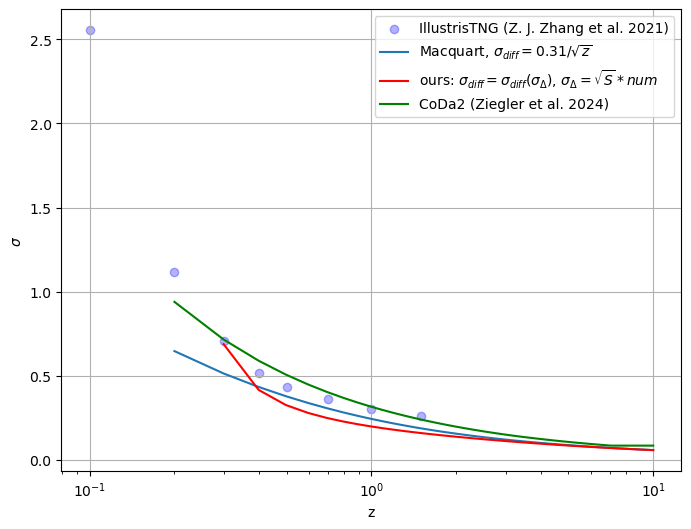

In [15]:
# Macquart F=0.31

plt.figure(figsize=(8, 6))
plt.scatter(df['z'], df['sigma'], 
            color='blue', 
            alpha=0.3, label='IllustrisTNG (Z. J. Zhang et al. 2021)')
plt.plot(z_range, sigmas_Macquart, 
         label=r'Macquart, $\sigma_{diff}=0.31/\sqrt{z}$')
plt.plot(z_range, sigmas_our, 
         color='red', 
         label=r'ours: $\sigma_{diff}=\sigma_{diff}(\sigma_\Delta)$, $\sigma_\Delta=\sqrt{S}*num$')
plt.plot(z_range, sigmas_CoDa2, 
         color='green',
         label='CoDa2 (Ziegler et al. 2024)')

plt.xlabel('z')
plt.ylabel('$\sigma$')
plt.xscale('log')
# plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()